In [ ]:
# =============================================================================
# Интерпретация KAN-модели PhysicsKAN (Exp 2.6.6)
# =============================================================================
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

# Добавляем корень проекта в путь
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from osc_tools.visualization.kan_plot import plot_kan_layer_grid
from scripts.evaluation.aggregate_reports import _create_model_from_config, _load_state_dict_safe
from scripts.evaluation.plot_model_marking import (
    _find_experiment_dir, _resolve_feature_mode, _resolve_sampling_strategy,
    _resolve_num_harmonics, _resolve_target_level, json_load
)

# === НАСТРОЙКИ ===
EXP_NAME = "Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug"
FIGURES_DIR = ROOT_DIR / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Experiment: {EXP_NAME}")
print(f"Figures will be saved to: {FIGURES_DIR}")

In [ ]:
# === Загрузка модели ===
exp_dir = _find_experiment_dir(EXP_NAME)
config = json_load(exp_dir / "config.json")

model = _create_model_from_config(config)
ckpt_path = exp_dir / "best_model.pt"
if not ckpt_path.exists():
    ckpt_path = exp_dir / "final_model.pt"

checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
_load_state_dict_safe(model, checkpoint, exp_dir.name, "notebook")
model.eval()

print(f"Модель: {config['model']['name']}")
print(f"Параметры: {config['model']['params']}")
print(f"Чекпоинт: {ckpt_path.name}")

In [8]:
# Загрузка модели PhysicsKAN из эксперимента 2.6.1
model, config, exp_dir = load_experiment_model(EXP_NAME)
print(f"Experiment Dir: {exp_dir}")

Experiment Dir: D:\Программирование\Fork\Scientific_research_osc_ML\experiments\Для_запуска_стат\Exp_2.6.1\Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug


## Визуализация KAN-слоёв в PhysicsKAN

PhysicsKAN содержит ConvKAN в блоке `processing_net`.
Мы посмотрим, какие формы функций активации выучены в первом сверточном KAN-слое и в первом слое классификатора.
Это помогает понять, какие нелинейности использует модель.

Input Features (InChannels * KernelSize): 288
Output Features (Filters): 16
Визуализация функций активации (первые 3x5)...


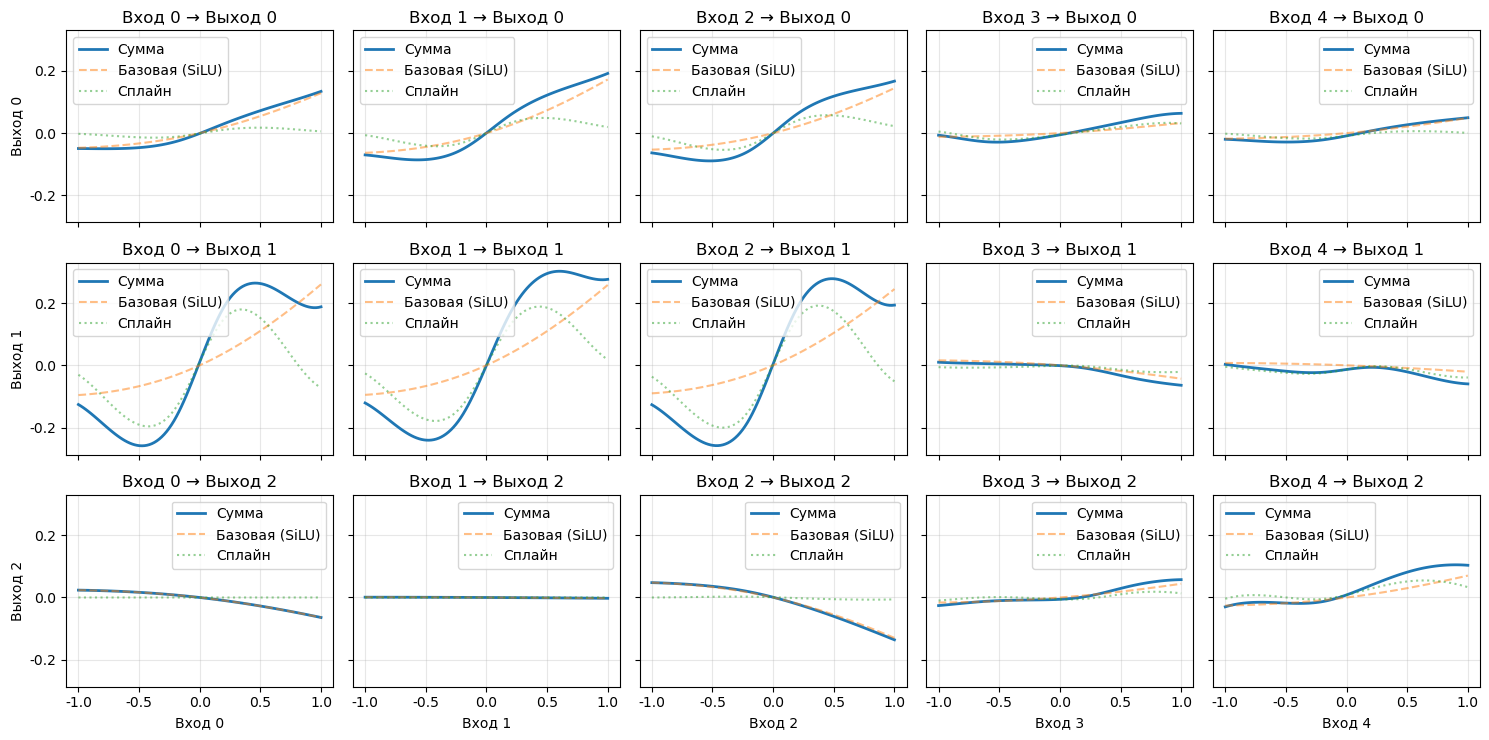

Визуализация классификатора (первые 3x5)...


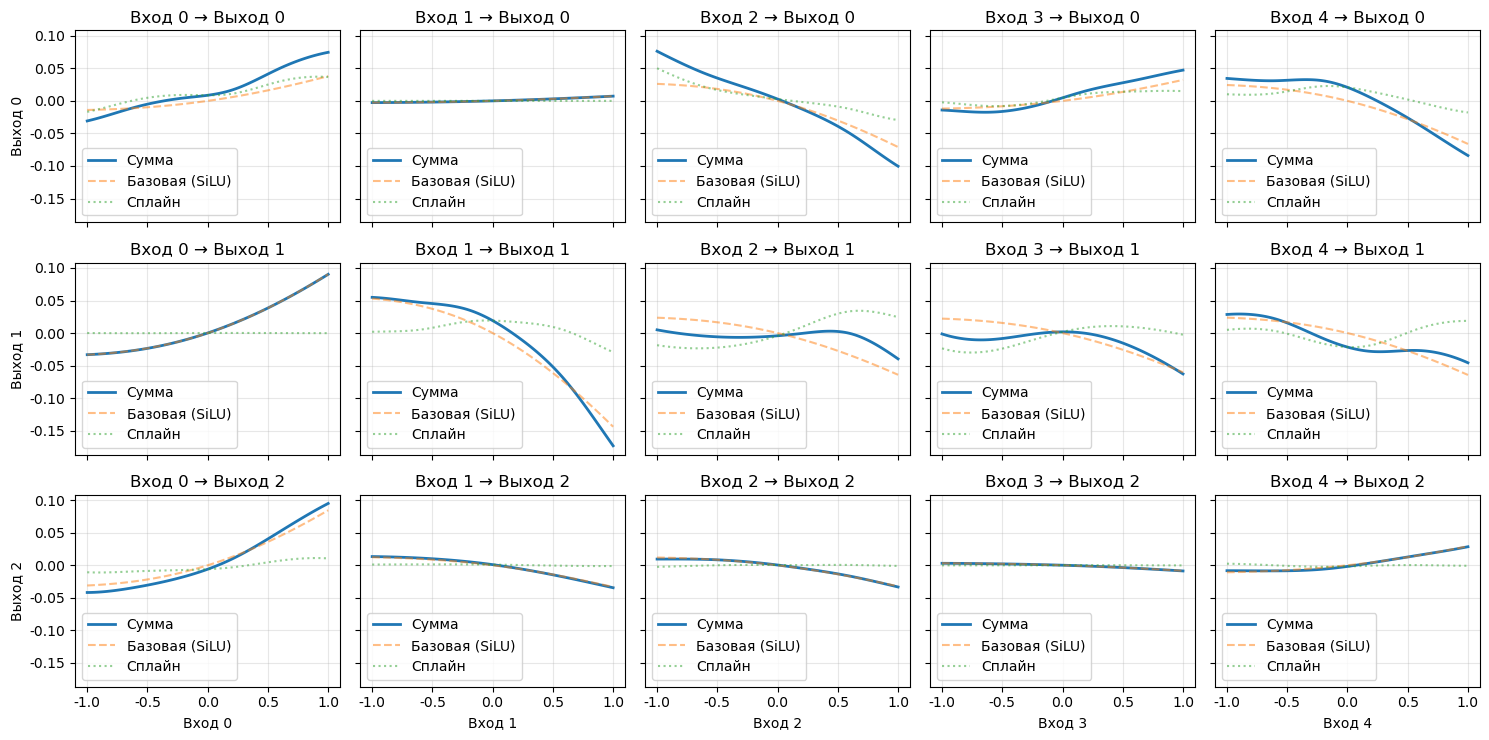

Графики сохранены в reports/figures


In [ ]:
# === Визуализация KAN-слоёв ===
out_dir = ROOT_DIR / 'reports' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

# Первый сверточный KAN-слой
conv_layer = model.processing_net.features[0]
kan_linear = conv_layer.kan_layer
print(f"Conv KAN Layer: in={kan_linear.in_features}, out={kan_linear.out_features}")

# Используем save_path для сохранения
fig = plot_kan_layer_grid(
    kan_linear, 
    max_inputs=5, 
    max_outputs=3,
    save_path=out_dir / f"{EXP_NAME}_kan_layer0.png",
    show=True
)
print(f"Сохранено: {out_dir / f'{EXP_NAME}_kan_layer0.png'}")

# Первый слой классификатора
clf_layer = model.processing_net.classifier[0]
print(f"Classifier KAN Layer: in={clf_layer.in_features}, out={clf_layer.out_features}")

fig_clf = plot_kan_layer_grid(
    clf_layer,
    max_inputs=5,
    max_outputs=3,
    save_path=out_dir / f"{EXP_NAME}_kan_classifier0.png",
    show=True
)
print(f"Сохранено: {out_dir / f'{EXP_NAME}_kan_classifier0.png'}")

## Важность связей и вклад арифметических слоёв

Далее мы оценим важность связей KAN на реальных данных (среднее $|\phi(x)|$)
и посмотрим базовые статистики по выходам `MultiplicationLayer` и `DivisionLayer`,
чтобы понять вклад физических преобразований в сигнал.

[DatasetManager] Найдены существующие файлы: train.csv, test.csv
Сбор входов KANLinear и расчёт важностей...
Найдено слоёв KANLinear: 5


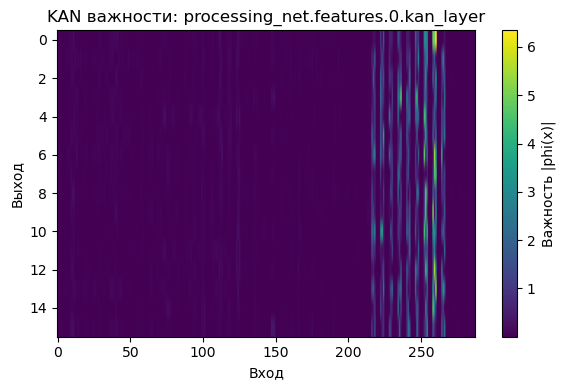

Средняя |x|: 0.8501435915629069
Средняя |x*y|: 1.296512206395467
Средняя |x/y|: 148443.14973958334


In [ ]:
# === Важность связей KAN и вклад арифметических слоёв ===
from torch.utils.data import DataLoader
from osc_tools.ml.kan_pruning import collect_kan_inputs, calculate_kan_importance

# Создание простого DataLoader для сбора активаций
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Используем уже загруженный датасет ds
loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

print("Сбор входов KANLinear...")
inputs = collect_kan_inputs(model, loader, device, max_batches=5, max_samples=1000)

print("Расчёт важностей |phi(x)|...")
importances = calculate_kan_importance(model, inputs, device)
print(f"Найдено KANLinear слоёв: {len(importances)}")

# === Визуализация матрицы важности ===
if importances:
    fig, axes = plt.subplots(1, min(3, len(importances)), figsize=(15, 5))
    if len(importances) == 1:
        axes = [axes]
    
    for idx, (layer_name, imp_tensor) in enumerate(list(importances.items())[:3]):
        scores = imp_tensor.numpy()
        ax = axes[idx]
        
        im = ax.imshow(scores, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=scores.max())
        ax.set_title(f'{layer_name}\nshape={scores.shape}')
        ax.set_xlabel('Входной нейрон')
        ax.set_ylabel('Выходной нейрон')
        plt.colorbar(im, ax=ax, label='|φ(x)|')
    
    plt.tight_layout()
    plt.savefig(out_dir / f"{EXP_NAME}_importance_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Сохранено: {out_dir / f'{EXP_NAME}_importance_heatmap.png'}")

# === Статистики по слоям ===
print("\nСтатистика важности по слоям:")
for layer_name, imp_tensor in importances.items():
    scores = imp_tensor.numpy()
    print(f"  {layer_name}: mean={scores.mean():.4f}, max={scores.max():.4f}, ", end='')
    print(f"zeros={np.sum(scores < 0.001) / scores.size * 100:.1f}%")

# === Вклад арифметических слоёв (Mult/Div) ===
if hasattr(model, 'mult') and hasattr(model, 'div'):
    print("\nВклад арифметических слоёв:")
    raw_stats, mult_stats, div_stats = [], [], []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
            mult_out = model.mult(x)
            div_out = model.div(x)
            
            raw_stats.append((x.abs().mean().item(), x.abs().max().item()))
            mult_stats.append((mult_out.abs().mean().item(), mult_out.abs().max().item()))
            div_stats.append((div_out.abs().mean().item(), div_out.abs().max().item()))
            if i >= 5:
                break
    
    print(f"  Raw input:  mean={np.mean([s[0] for s in raw_stats]):.4f}, max={np.mean([s[1] for s in raw_stats]):.4f}")
    print(f"  Mult layer: mean={np.mean([s[0] for s in mult_stats]):.4f}, max={np.mean([s[1] for s in mult_stats]):.4f}")
    print(f"  Div layer:  mean={np.mean([s[0] for s in div_stats]):.4f}, max={np.mean([s[1] for s in div_stats]):.4f}")
else:
    print("\nМодель не содержит MultiplicationLayer/DivisionLayer")

## Выводы

### Интерпретация результатов:

1. **Функции активации KAN** - показывают нелинейные преобразования, которые выучила модель.
   - Base component (синий) - линейная часть (SiLU * x)
   - Spline component (оранжевый) - изученный сплайн
   - Total (base+spline, зелёный) - финальная функция

2. **Матрица важности** - показывает |φ(x)| для каждой связи вход-выход.
   - Высокие значения = важные связи
   - Низкие значения = можно удалить (pruning)

3. **Арифметические слои (Mult/Div)** - физически интерпретируемые преобразования.
   - Если Div даёт большие значения - возможны численные проблемы
   - Результаты из Exp 2.6.5: mult критичен (удаление сильно падает F1), div менее важен